In [ ]:
# ===============================
# IMPORT LIBRARY LENGKAP
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                     # untuk confusion matrix heatmap
import warnings
warnings.filterwarnings("ignore")         # opsional agar output rapi

# Sklearn utilities
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Save model
import joblib
import os


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Load data
file_path = '/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv'
df = pd.read_csv(file_path)

df.head()

,Hypothyroidism,Creatinine,Diabetes Mellitus (DM),Alanin Aminotransferaz (ALT),Low Density Lipoprotein (LDL),Hemoglobin (HGB),Coronary Artery Disease (CAD),Total Body Fat Ratio (TBFR) (%),Total Body Water (TBW),Height,...,Aspartat Aminotransferaz (AST),Glomerular Filtration Rate (GFR),Glucose,TC/HDL Ratio,LDL/HDL Ratio,Atherogenic Index,Triglyceride/HDL Ratio,Non-Lean Mass (NLM),Body Fat/Water Ratio,De Ritis Ratio
0,0,1.36,1,83.0,6.5,37.8,0,25.213043,36.87740,160.0,...,13.6,54.218927,130.0,6.243386,0.343915,5.243386,15.555556,-5.786957,0.683699,0.163855
1,0,0.81,0,16.0,75.0,14.3,0,13.352632,34.10012,170.0,...,25.0,94.586269,100.0,2.000000,1.000000,1.000000,0.866667,-29.647368,0.391571,1.562500
2,0,0.81,0,15.0,78.0,14.5,0,20.100000,34.67564,160.0,...,20.0,99.353543,100.0,2.083333,1.083333,1.083333,0.944444,-19.900000,0.579658,1.333333
3,0,0.81,0,14.0,78.0,15.1,0,21.885714,39.11164,170.0,...,23.0,99.353543,100.0,2.000000,1.040000,1.000000,0.866667,-8.114286,0.559570,1.642857
4,0,0.72,0,14.0,80.0,12.3,0,29.500000,26.26800,150.0,...,25.0,93.612393,98.0,2.384615,1.230769,1.384615,1.076923,-20.500000,1.123039,1.785714


In [4]:
# ==============================
# 1. Siapkan data
# ==============================
target_col = "Gallstone Status"
X = df.drop(columns=[target_col]).values
y = df[target_col].values

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE hanya untuk training
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scaler untuk LR
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_res)
X_test_lr = scaler.transform(X_test)

In [5]:
# ==============================
# 2. Definisikan models
# ==============================
models = {
    "LR": LogisticRegression(max_iter=500),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGB": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                         random_state=42, eval_metric="logloss"),
    "LGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                           random_state=42)
}


=== TRAINING MODEL: LR ===
Accuracy: 0.7805, Precision: 0.5532, Recall: 0.8125, F1: 0.6582, ROC-AUC: 0.8036


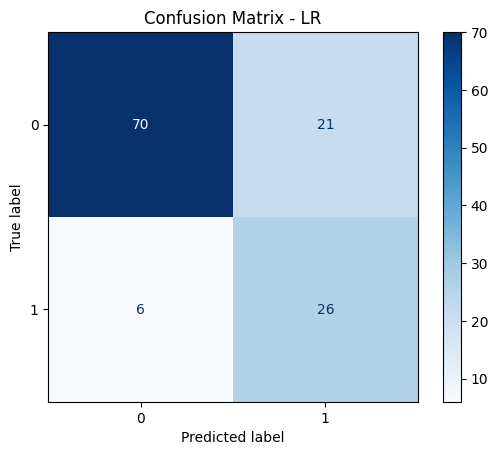

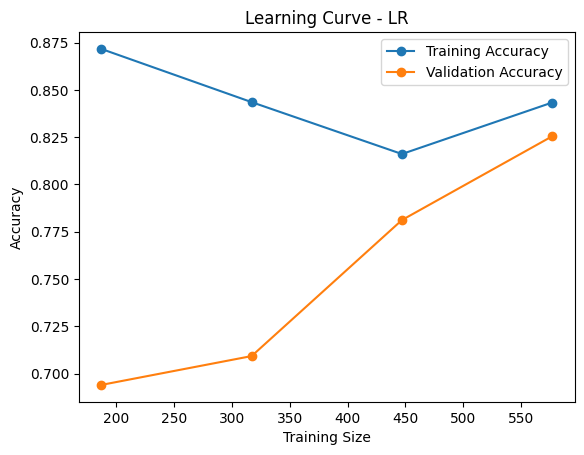

<Figure size 640x480 with 0 Axes>

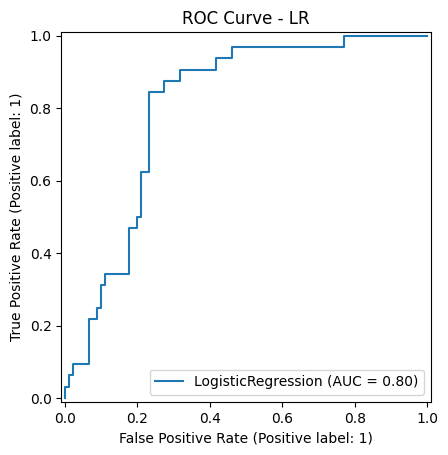

✅ Model LR disimpan

=== TRAINING MODEL: RF ===
Accuracy: 0.7154, Precision: 0.4595, Recall: 0.5312, F1: 0.4928, ROC-AUC: 0.7922


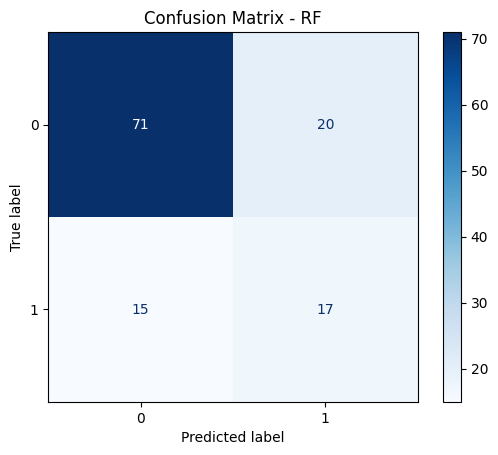

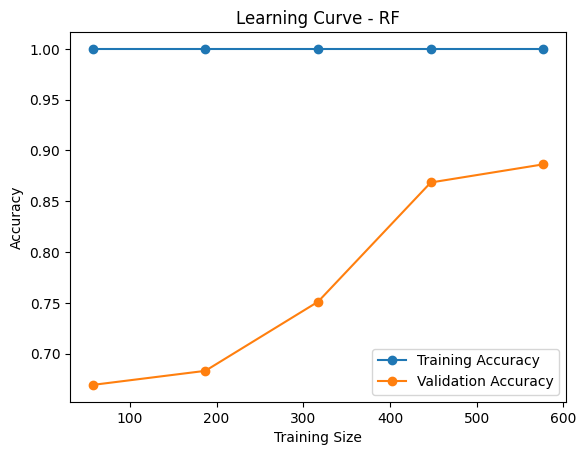

<Figure size 640x480 with 0 Axes>

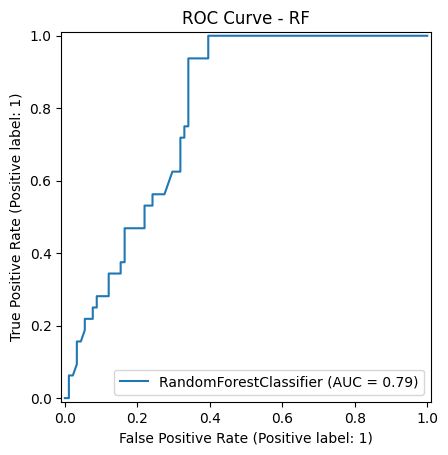

✅ Model RF disimpan

=== TRAINING MODEL: XGB ===
Accuracy: 0.7073, Precision: 0.4412, Recall: 0.4688, F1: 0.4545, ROC-AUC: 0.8170


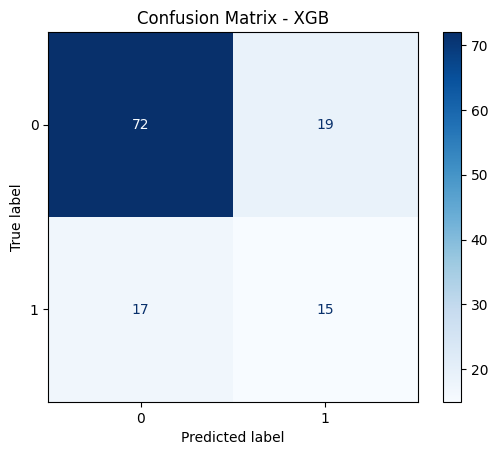

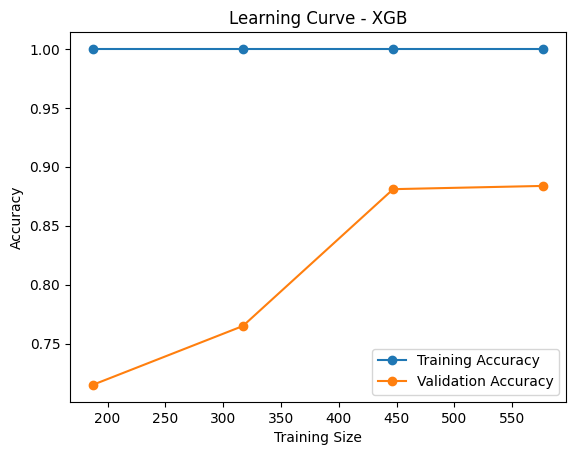

<Figure size 640x480 with 0 Axes>

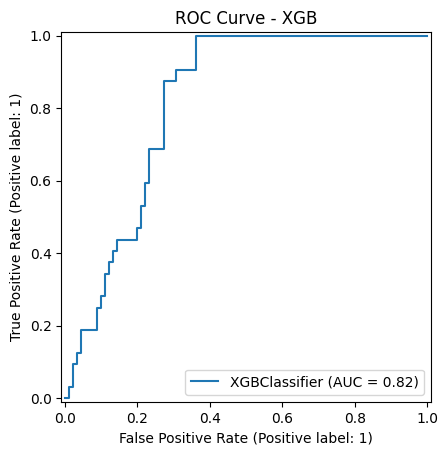

✅ Model XGB disimpan

=== TRAINING MODEL: LGBM ===
[LightGBM] [Info] Number of positive: 361, number of negative: 361
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5760
[LightGBM] [Info] Number of data points in the train set: 722, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

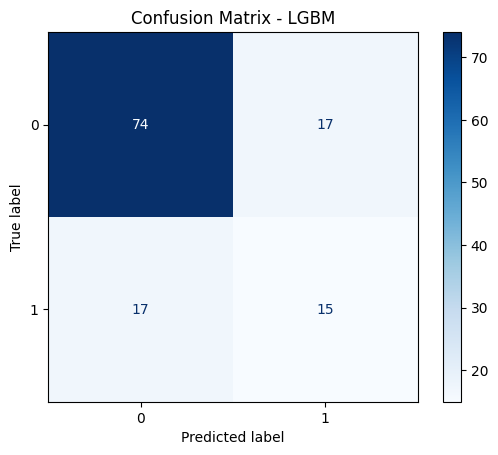

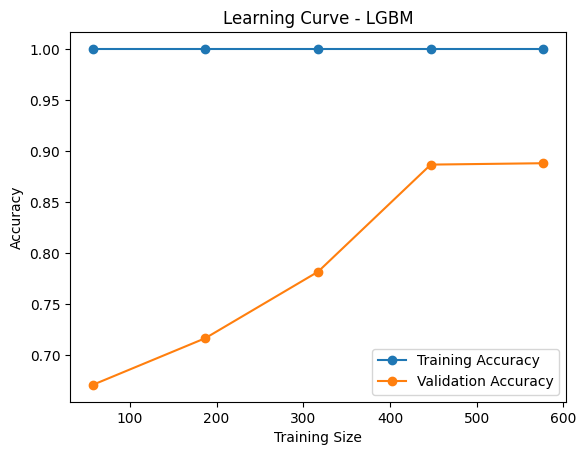

<Figure size 640x480 with 0 Axes>

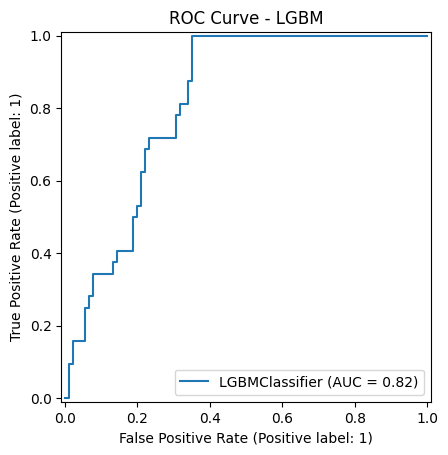

✅ Model LGBM disimpan


In [6]:
results = []
# ===============================
# 🔴 PERBAIKAN 1 — OUTPUT DIRECTORY
# ===============================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/Classic Clasifiers/Base Model/"
os.makedirs(output_dir, exist_ok=True)

for name, model in models.items():
    print(f"\n=== TRAINING MODEL: {name} ===")

    # Pilih data yang diskalakan untuk LR
    if name == "LR":
        X_tr, X_te = X_train_lr, X_test_lr
    else:
        X_tr, X_te = X_train_res, X_test

    # Fit model
    model.fit(X_tr, y_train_res)

    # Prediksi
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:,1]

    # Hitung metrik
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    # Simpan hasil
    results.append([name, acc, prec, rec, f1, roc])

    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}")

    # ==============================
    # Confusion Matrix
    # ==============================
    plt.figure()
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ==============================
    # Learning Curve
    # ==============================
    plt.figure()
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_tr, y_train_res, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    plt.plot(train_sizes, train_mean, 'o-', label='Training Accuracy')
    plt.plot(train_sizes, val_mean, 'o-', label='Validation Accuracy')
    plt.title(f'Learning Curve - {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ==============================
    # ROC Curve
    # ==============================
    plt.figure()
    RocCurveDisplay.from_estimator(model, X_te, y_test)
    plt.title(f'ROC Curve - {name}')
    plt.show()

    # ===============================
    # 🔴 PERBAIKAN 2 — SAVE MODEL
    # ===============================
    joblib.dump(
        model,
        os.path.join(output_dir, f"{name}_HO_model.pkl")
    )

    print(f"✅ Model {name} disimpan")



In [7]:
# ==============================
# Tampilkan semua hasil evaluasi
# ==============================
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
display(results_df.sort_values(by='ROC-AUC', ascending=False))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,LGBM,0.723577,0.468750,0.46875,0.468750,0.818338
2,XGB,0.707317,0.441176,0.46875,0.454545,0.816964
0,LR,0.780488,0.553191,0.81250,0.658228,0.803571
1,RF,0.715447,0.459459,0.53125,0.492754,0.792239


In [8]:
# ===============================
# IMPORT
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ===============================
# 🔴 PERBAIKAN 1 — LOAD DATA + DEFINE X, y
# ===============================
data_path = "/content/drive/MyDrive/Tesis/Eksperimen/Dataset/Data Gabungan/fix_data_gabungan_fe_tambahan_2.csv"
df = pd.read_csv(data_path)

target_col = "Gallstone Status"
X = df.drop(columns=[target_col]).values
y = df[target_col].values


In [10]:
 #===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [11]:
# ===============================
# MODEL DEFINITIONS
# ===============================
models = {
    "LR": LogisticRegression(max_iter=500, random_state=42),
    "RF": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGB": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1
    ),
    "LGBM": LGBMClassifier(
        random_state=42,
        n_jobs=-1
    )
}

In [12]:
# ===============================
# PARAMETER SPACE
# ===============================
param_space = {
    "LR": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__class_weight": [None, "balanced"]
    },

    "RF": {
        "model__n_estimators": [200, 300, 400],
        "model__max_depth": [5, 8, 12],
        "model__min_samples_split": [5, 10, 15],
        "model__min_samples_leaf": [3, 5, 7],
        "model__max_features": ["sqrt", 0.5, 0.7],
        "model__class_weight": ["balanced"]
    },

    "XGB": {
        "model__n_estimators": [100, 150, 200],
        "model__learning_rate": [0.01, 0.02, 0.03],
        "model__max_depth": [3, 4],
        "model__subsample": [0.6, 0.7],
        "model__colsample_bytree": [0.6, 0.7],
        "model__reg_alpha": [0.5, 1],
        "model__reg_lambda": [2, 3],
        "model__scale_pos_weight": [1, 3, 5]
    },

    "LGBM": {
        "model__n_estimators": [200, 300],
        "model__learning_rate": [0.005, 0.01],
        "model__max_depth": [3, 5],
        "model__num_leaves": [5, 7, 15],
        "model__min_child_samples": [20, 30, 40],
        "model__subsample": [0.6, 0.7],
        "model__colsample_bytree": [0.6, 0.7],
        "model__reg_alpha": [0.1, 0.3, 0.5],
        "model__reg_lambda": [1.0, 2.0, 3.0],
        "model__min_split_gain": [0.05, 0.1]
    }
}

best_models = {}
best_scores = {}


In [13]:
# ===============================
# 🔴 PERBAIKAN 2 — OUTPUT DIRECTORY
# ===============================
output_dir = "/content/drive/MyDrive/Tesis/Fix FE HO/Classic Clasifiers/Tuned Model/"
os.makedirs(output_dir, exist_ok=True)


In [14]:
# ===============================
# RANDOM SEARCH LOOP
# ===============================
for name, model in models.items():
    print(f"\n=========== RANDOM SEARCH — {name} ===========")

    if name == "LR":
        pipe = ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])
    else:
        pipe = ImbPipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

    rs = RandomizedSearchCV(
        pipe,
        param_distributions=param_space[name],
        n_iter=10,
        scoring="roc_auc",
        cv=5,
        random_state=42,
        n_jobs=-1
    )

    rs.fit(X_train, y_train)

    best_models[name] = rs.best_estimator_
    best_scores[name] = rs.best_score_

    print("Best Params:", rs.best_params_)
    print("Best CV ROC-AUC:", rs.best_score_)

    # 🔴 PERBAIKAN 3 — SAVE MODEL
    joblib.dump(
        rs.best_estimator_,
        os.path.join(output_dir, f"{name}_RandomSearch.pkl")
    )



=========== RANDOM SEARCH — LR ===========
Best Params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__class_weight': None, 'model__C': 1}
Best CV ROC-AUC: 0.8492580494087344

=========== RANDOM SEARCH — RF ===========
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 12, 'model__class_weight': 'balanced'}
Best CV ROC-AUC: 0.8645963587401944

=========== RANDOM SEARCH — XGB ===========
Best Params: {'model__subsample': 0.7, 'model__scale_pos_weight': 1, 'model__reg_lambda': 2, 'model__reg_alpha': 0.5, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.7}
Best CV ROC-AUC: 0.855873726729891

=========== RANDOM SEARCH — LGBM ===========
[LightGBM] [Info] Number of positive: 361, number of negative: 361
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You ca

In [15]:
# ===============================
# EVALUATION TEST SET
# ===============================
metrics_result = {}
cm_dict = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics_result[name] = [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba)
    ]

    cm_dict[name] = confusion_matrix(y_test, y_pred)


In [16]:
# ===============================
# METRIC TABLE
# ===============================
df_metrics = pd.DataFrame(
    metrics_result,
    index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).T

display(df_metrics)


,Accuracy,Precision,Recall,F1,ROC-AUC
LR,0.764228,0.533333,0.75000,0.623377,0.799107
RF,0.699187,0.441860,0.59375,0.506667,0.795330
XGB,0.699187,0.441860,0.59375,0.506667,0.780563
LGBM,0.682927,0.428571,0.65625,0.518519,0.781250


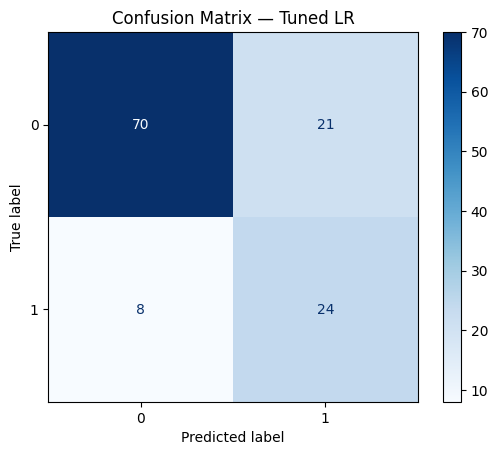

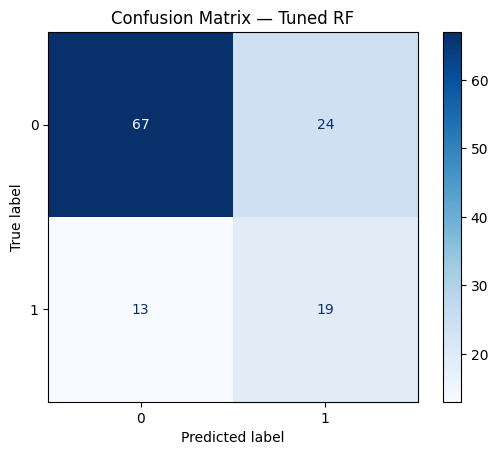

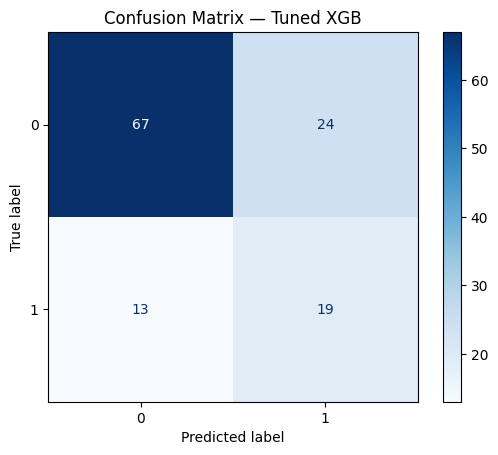

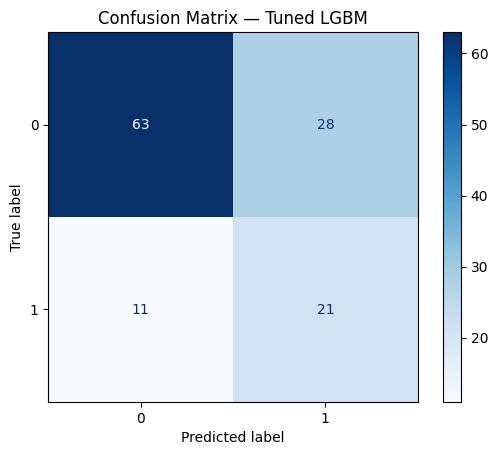

In [17]:
# ===============================
# CONFUSION MATRIX
# ===============================
for name, cm in cm_dict.items():
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix — Tuned {name}")
    plt.show()


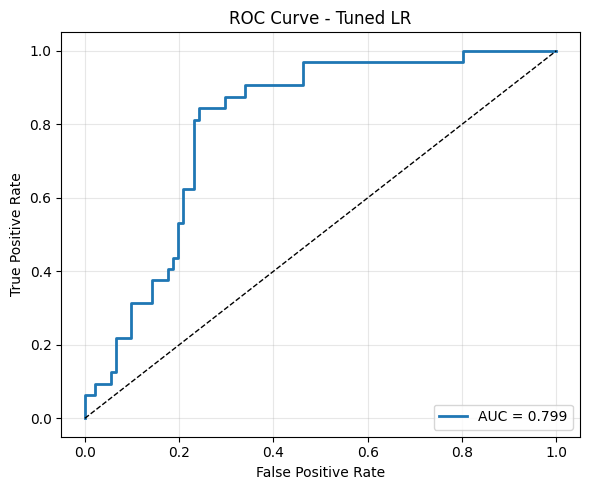

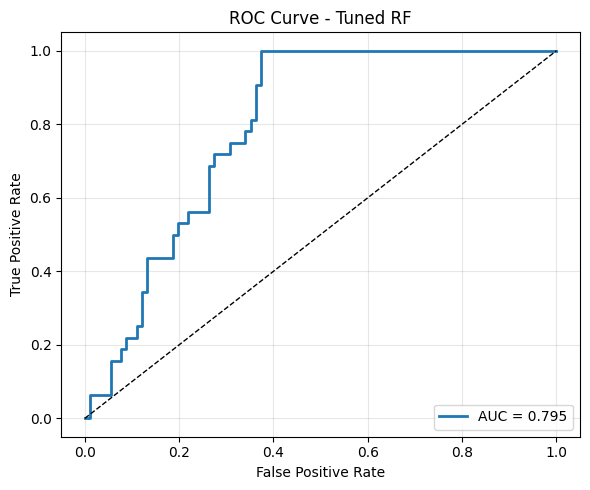

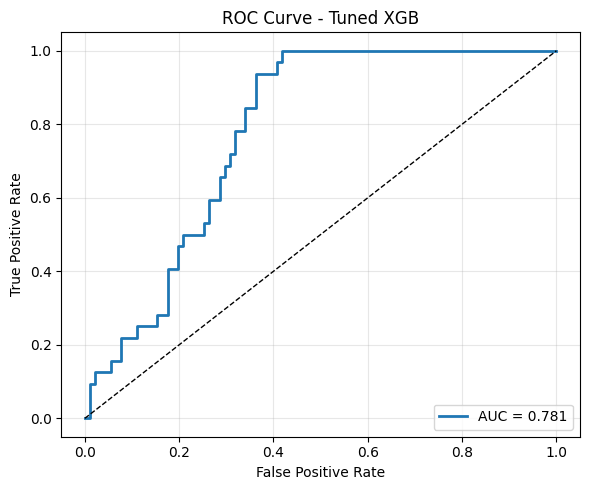

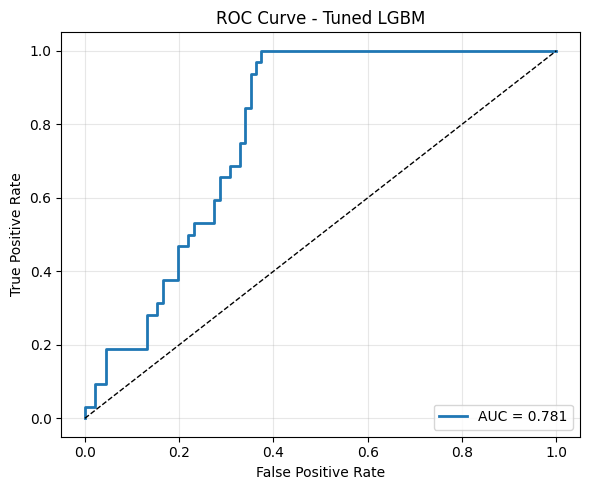

In [18]:
# ===============================
# ROC CURVE (SATU PER SATU)
# ===============================
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

for name, model in best_models.items():
    # Prediksi probabilitas
    y_proba = model.predict_proba(X_test)[:, 1]

    # Hitung ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    # Plot
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Tuned {name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


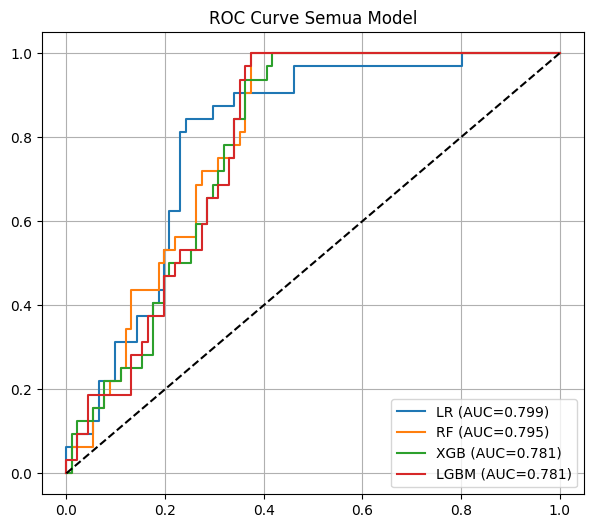

In [19]:
# ===============================
# ROC CURVE
# ===============================
plt.figure(figsize=(7,6))
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.grid()
plt.title("ROC Curve Semua Model")
plt.show()

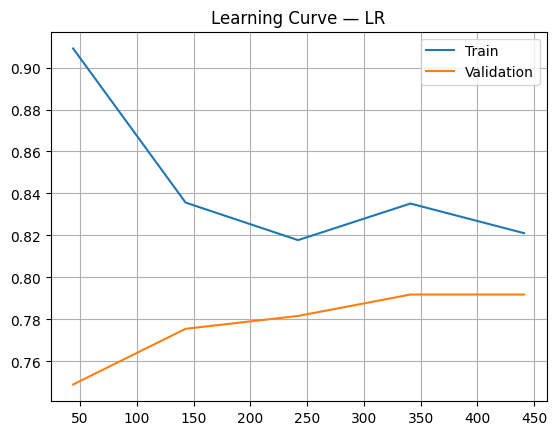

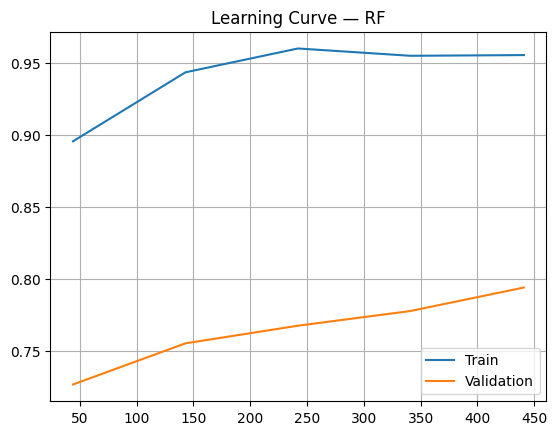

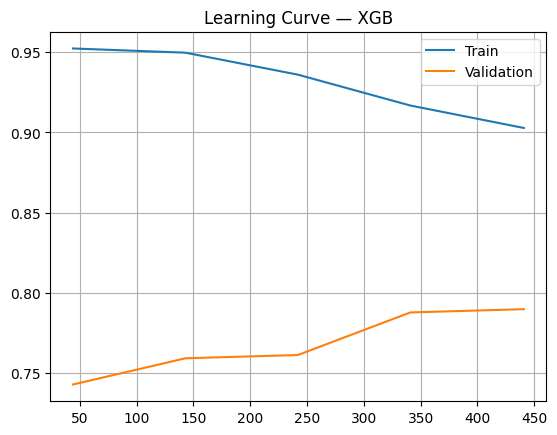

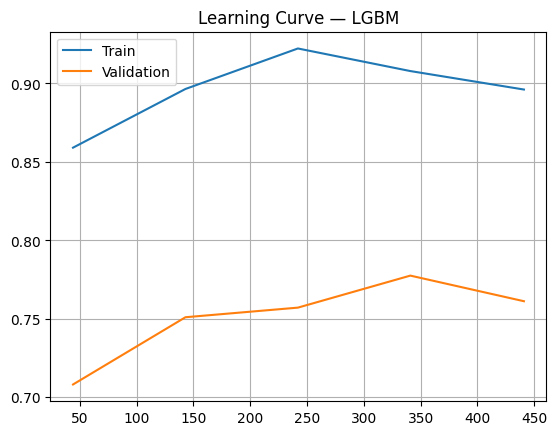

In [20]:
# ===============================
# 🔴 PERBAIKAN 4 — LEARNING CURVE (PIPELINE AMAN)
# ===============================
for name, model in best_models.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=10,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(f"Learning Curve — {name}")
    plt.legend()
    plt.grid()
    plt.show()